# Payoff structures — NIFTY options

Straddle · strangle · **vertical spreads (credit and debit)** · iron fly · iron condor ·
naked call and put.

One trading day: **27 Jan 2026**, expiry **10 Feb 2026**, lot size **65**.

The forward and the discount are derived from the option prices, not read from the data — see
[`docs/calculations.md`](../docs/calculations.md).

A strategy is a **list of legs**. Every figure below comes from one payoff function and one
metrics function — no per-strategy code.

**Every structure is drawn twice — one position, two coordinate systems.** The left panel reads
the payoff against terminal spot $S_T$, the right against the forward $F$. Because
$S_T = F - b$ the second is the first translated by the basis: the caps are identical and every
breakeven differs by exactly $b$.

## 1. Setup

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE = ROOT / "Data" / "sample" / "chain_2026-01-27.parquet"

# NIFTY lot size, confirmed 65 on 19 Aug 2026 (map #1). Margin mechanics stay open in issue #4.
LOT_SIZE = 65

TRADING_DAYS_PER_YEAR = 252  # established in issue #2

## 2. The data

NIFTY option chain, 1-minute bars, one session.

- `ts` is **UTC**. Source options are IST stamped at bar close, greeks UTC at bar open — a naive join
  returns zero rows and no warning.
- `dte_days` is a **trading-day clock**: one session consumes exactly 1.0, overnight and weekends none.
- Prices are the bar close, which is what `last` holds.

In [2]:
chain = pd.read_parquet(SAMPLE)
chain["ist"] = chain.ts + pd.Timedelta(hours=5, minutes=30)

print(f"rows      {len(chain):,}")
print(f"session   {chain.ist.min():%H:%M} -> {chain.ist.max():%H:%M} IST on {chain.ist.dt.date.iloc[0]}")
print(f"strikes   {chain.strike.nunique()}  ({chain.strike.min():.0f} - {chain.strike.max():.0f})")
print(f"dte_days  {chain.dte_days.max():.4f} at open -> {chain.dte_days.min():.4f} at close")
chain.head(3)

rows      23,581
session   09:15 -> 15:30 IST on 2026-01-27
strikes   94  (23300 - 27950)
dte_days  11.0000 at open -> 10.0000 at close


,ts,strike,option_type,Open,High,Low,Close,Volume,OpenInterest,Ticker,...,delta,gamma,theta,vega,rho,vanna,volga,charm,spot,ist
0,2026-01-27 03:45:00,23350.0,PE,19.15,19.35,19.0,19.0,1170,0,NIFTY10FEB2623350PE.NFO,...,-0.040644,0.000077,-4.294955,4.589929,-0.454762,-0.006859,0.628664,0.006734,25113.05,2026-01-27 09:15:00
1,2026-01-27 03:45:00,23400.0,PE,22.05,22.25,20.5,20.5,1755,20280,NIFTY10FEB2623400PE.NFO,...,-0.043716,0.000082,-4.531928,4.868650,-0.489155,-0.007188,0.645895,0.007020,25113.05,2026-01-27 09:15:00
2,2026-01-27 03:45:00,23450.0,PE,23.75,23.75,21.4,21.4,1820,4355,NIFTY10FEB2623450PE.NFO,...,-0.045958,0.000087,-4.658043,5.068765,-0.514183,-0.007489,0.663581,0.007221,25113.05,2026-01-27 09:15:00


### Moment

Midday IST — liquid, clear of the open and close auctions.

In [3]:
SNAPSHOT_TIME = pd.Timestamp("2026-01-27 12:00:00")

snap = chain[chain.ist == SNAPSHOT_TIME].copy()

SPOT = float(snap.spot.iloc[0])
DTE  = float(snap.dte_days.iloc[0])
T    = DTE / TRADING_DAYS_PER_YEAR

# Not inputs. Section 3 derives the forward and the discount from the option prices and
# grades the result against these two columns.
SOURCE_FORWARD  = float(snap.forward.iloc[0])
SOURCE_DISCOUNT = float(snap.discount.iloc[0])

print(f"spot      {SPOT:,.2f}")
print(f"dte_days  {DTE:.4f}   ->  T = {DTE:.4f}/252 = {T:.6f} years")
print(f"legs available: {len(snap)} across {snap.strike.nunique()} strikes")

spot      25,100.25
dte_days  10.5600   ->  T = 10.5600/252 = 0.041905 years
legs available: 58 across 49 strikes


## 3. Implied forward and discount

The forward and the discount factor are **derived from the option prices**, not read from the
data. Full derivation in [`docs/calculations.md`](../docs/calculations.md).

Put-call parity is an identity for European options on the same underlying, strike and expiry.
No model, no volatility, no distributional assumption:

$$C(K) - P(K) = D\,(F - K)$$

Read as a function of $K$ it is already a straight line:

$$\underbrace{C(K) - P(K)}_{y} \;=\; \underbrace{DF}_{a} \;+\; \underbrace{(-D)}_{m}\,K$$

So one ordinary least squares fit of $y$ on $K$ recovers both unknowns at once:

$$\hat D = -m \qquad \hat F = \frac{a}{\hat D} = -\frac{a}{m}$$

Only strikes quoting **both** a call and a put can enter — parity needs a pair.

**The gate.** OLS returns a number whether the input deserves one or not, so a fit is used only
if $n \ge 5$ and the implied rate $\hat r = -\ln \hat D / T$ falls inside $(0\%,\ 30\%)$.
Rejected minutes give $\hat D$ above 1 — a negative rate over two weeks — which would render as
a plausible-looking chart that is wrong. Those minutes are out of scope for v1 and are not
shown.

In [4]:
pairs = snap.pivot_table(index="strike", columns="option_type", values="last").dropna()
K = pairs.index.to_numpy(float)
y = (pairs.CE - pairs.PE).to_numpy(float)

m, a = np.polyfit(K, y, 1)           # y = a + m*K
DISCOUNT = -m
FORWARD = a / DISCOUNT
RATE = -np.log(DISCOUNT) / T
r2 = np.corrcoef(K, y)[0, 1] ** 2

assert len(pairs) >= 5, f"only {len(pairs)} paired strikes - fit rejected"
assert 0 < RATE < 0.30, f"implied rate {RATE:.2%} outside (0%, 30%) - fit rejected"

print(f"paired strikes   {len(pairs)}   ({K.min():,.0f} - {K.max():,.0f})")
print(f"fit              C - P = {a:,.2f} + {m:.6f} K      R2 = {r2:.6f}")
print(f"discount         {DISCOUNT:.6f}")
print(f"forward          {FORWARD:,.2f}    (basis {FORWARD - SPOT:+.2f} points over spot)")
print(f"implied rate     {RATE:.2%}   gate (0%, 30%): pass")

# Graded against the two columns solved independently upstream.
print()
print(f"{'':<12}{'ours':>14}{'source':>14}{'diff':>12}")
print(f"{'discount':<12}{DISCOUNT:>14.6f}{SOURCE_DISCOUNT:>14.6f}{DISCOUNT - SOURCE_DISCOUNT:>+12.6f}")
print(f"{'forward':<12}{FORWARD:>14,.2f}{SOURCE_FORWARD:>14,.2f}{FORWARD - SOURCE_FORWARD:>+12.2f}")
assert abs(FORWARD - SOURCE_FORWARD) < 0.01, "forward disagrees with the source"
assert abs(DISCOUNT - SOURCE_DISCOUNT) < 1e-6, "discount disagrees with the source"

paired strikes   9   (24,500 - 25,500)
fit              C - P = 25,054.69 + -0.993480 K      R2 = 0.999892
discount         0.993480
forward          25,219.12    (basis +118.87 points over spot)
implied rate     15.61%   gate (0%, 30%): pass

                      ours        source        diff
discount          0.993480      0.993480   +0.000000
forward          25,219.12     25,219.12       +0.00


### The basis

The at-the-money strike is the one nearest the **forward**, not the spot. Here the two differ by
more than two strike intervals and select different strikes — so this is not a rounding detail,
it decides which options every structure below holds.

`docs/calculations.md` §1 settles which one is correct, and **this notebook anchors on the
forward**. The gap between them is the basis

$$b \;=\; \hat F - S$$

which is also the only quantity separating the two panels in §7.

In [5]:
quoted_both = sorted(snap.groupby("strike").option_type.nunique().pipe(lambda q: q[q == 2]).index)
atm_from_spot    = min(quoted_both, key=lambda k: abs(k - SPOT))
atm_from_forward = min(quoted_both, key=lambda k: abs(k - FORWARD))

BASIS = FORWARD - SPOT

print(f"spot      {SPOT:,.2f}   -> nearest paired strike {atm_from_spot:,.0f}")
print(f"forward   {FORWARD:,.2f}   -> nearest paired strike {atm_from_forward:,.0f}")
print(f"basis     b = F_hat - S = {BASIS:+.2f} points")

# Guards the claim, not the chart layout: if these ever coincide the basis has stopped mattering.
assert atm_from_forward != atm_from_spot, "the anchors agree - the basis has stopped mattering"
print(f"the anchors disagree: {atm_from_forward:,.0f} (forward) vs {atm_from_spot:,.0f} (spot)")

spot      25,100.25   -> nearest paired strike 25,100
forward   25,219.12   -> nearest paired strike 25,200
basis     b = F_hat - S = +118.87 points
the anchors disagree: 25,200 (forward) vs 25,100 (spot)


## 4. Legs and strategies

A **leg** is one contract: strike, type, direction, quantity, entry price.
A **strategy** is a list of legs — an iron condor is four legs, not a type.

In [6]:
@dataclass(frozen=True)
class Leg:
    strike: float
    option_type: str      # "CE" or "PE"
    direction: int        # +1 bought, -1 sold
    entry_price: float
    iv: float
    quantity: int = 1

    @property
    def is_call(self):
        return self.option_type == "CE"

    def __repr__(self):
        side = "B" if self.direction > 0 else "S"
        return f"{side} {self.quantity}x {self.strike:.0f} {self.option_type} @ {self.entry_price:.2f}"


def leg_from_chain(strike, option_type, direction, quantity=1, snapshot=None):
    '''Build a Leg from the observed chain. Entry price is the 1-min bar close.'''
    snapshot = snap if snapshot is None else snapshot
    row = snapshot[(snapshot.strike == strike) & (snapshot.option_type == option_type)]
    if row.empty:
        raise KeyError(f"{strike:.0f} {option_type} not quoted at this minute")
    row = row.iloc[0]
    return Leg(strike, option_type, direction, float(row.last), float(row.iv), quantity)

### Strikes

Outer legs sit at the **nearest quoted strike at least $w$ points away**, not at
$\text{ATM} \pm w$ — the chain has gaps and an unquoted strike cannot be traded. The width is
then read back off the strikes actually used, never assumed from the nominal offset.

In [7]:
quoted = snap.groupby("strike").option_type.nunique()
both_sides = set(quoted[quoted == 2].index)          # strikes with a live CE and PE

# A fly or condor wing is a single option, so it does not need the strike quoted on both sides -
# and at this minute nothing above 25,500 is. Restricting the wings to `both_sides` would leave
# the far call wing unbuildable.
ce_strikes = set(snap.loc[snap.option_type == "CE", "strike"])
pe_strikes = set(snap.loc[snap.option_type == "PE", "strike"])

WING   = 300     # strangle
NEAR   = 300     # fly wings
FAR    = 600     # condor wings
SPREAD = 300     # vertical spreads


def build_strategies(atm):
    """Every structure in this notebook, built around one at-the-money strike."""
    otm_call = min(k for k in both_sides if k >= atm + WING)
    otm_put  = max(k for k in both_sides if k <= atm - WING)
    fly_call = min(k for k in ce_strikes if k >= atm + NEAR)
    fly_put  = max(k for k in pe_strikes if k <= atm - NEAR)
    con_call = min(k for k in ce_strikes if k >= atm + FAR)
    con_put  = max(k for k in pe_strikes if k <= atm - FAR)
    up_call  = min(k for k in ce_strikes if k >= atm + SPREAD)
    dn_put   = max(k for k in pe_strikes if k <= atm - SPREAD)

    strategies = {
        "Long Straddle":    [leg_from_chain(atm, "CE", +1), leg_from_chain(atm, "PE", +1)],
        "Short Straddle":   [leg_from_chain(atm, "CE", -1), leg_from_chain(atm, "PE", -1)],
        "Long Strangle":    [leg_from_chain(otm_call, "CE", +1), leg_from_chain(otm_put, "PE", +1)],
        # Vertical spreads. Same two strikes each time; the signs decide debit or credit.
        "Bull Call Spread": [leg_from_chain(atm, "CE", +1), leg_from_chain(up_call, "CE", -1)],
        "Bear Call Spread": [leg_from_chain(atm, "CE", -1), leg_from_chain(up_call, "CE", +1)],
        "Bull Put Spread":  [leg_from_chain(atm, "PE", -1), leg_from_chain(dn_put, "PE", +1)],
        "Bear Put Spread":  [leg_from_chain(atm, "PE", +1), leg_from_chain(dn_put, "PE", -1)],
        "Iron Fly":         [leg_from_chain(atm, "CE", -1), leg_from_chain(atm, "PE", -1),
                             leg_from_chain(fly_call, "CE", +1), leg_from_chain(fly_put, "PE", +1)],
        "Iron Condor":      [leg_from_chain(fly_call, "CE", -1), leg_from_chain(fly_put, "PE", -1),
                             leg_from_chain(con_call, "CE", +1), leg_from_chain(con_put, "PE", +1)],
        "Naked Long Call":  [leg_from_chain(atm, "CE", +1)],
        "Naked Short Call": [leg_from_chain(atm, "CE", -1)],
        "Naked Long Put":   [leg_from_chain(atm, "PE", +1)],
        "Naked Short Put":  [leg_from_chain(atm, "PE", -1)],
    }
    strikes = {"atm": atm, "otm_call": otm_call, "otm_put": otm_put,
               "fly_call": fly_call, "fly_put": fly_put,
               "con_call": con_call, "con_put": con_put,
               "up_call": up_call, "dn_put": dn_put}
    return strategies, strikes


# One position per structure, anchored on the forward.
ATM = min(both_sides, key=lambda k: abs(k - FORWARD))
STRATEGIES, STRIKES = build_strategies(ATM)


@dataclass(frozen=True)
class Framing:
    """A coordinate system for the payoff x-axis. Data, not a code path."""

    name: str        # "spot" | "forward"
    symbol: str      # the axis variable
    level: float     # reference line, and the centre of the plotted window
    shift: float     # added to every x-coordinate: 0 for spot, b for forward


SPOT_FRAMING    = Framing("spot",    "S_T", SPOT,    0.0)
FORWARD_FRAMING = Framing("forward", "F",   FORWARD, BASIS)
FRAMINGS = (SPOT_FRAMING, FORWARD_FRAMING)


def pair(lo, hi):
    return f"{lo:,.0f} / {hi:,.0f}"


print(f"ATM (nearest the forward)  {ATM:,.0f}")
print(f"  strangle wings           {pair(STRIKES['otm_put'], STRIKES['otm_call'])}")
print(f"  vertical spread strikes  {pair(STRIKES['dn_put'], STRIKES['up_call'])}")
print(f"  fly wings                {pair(STRIKES['fly_put'], STRIKES['fly_call'])}")
print(f"  condor wings             {pair(STRIKES['con_put'], STRIKES['con_call'])}")

print(f"\n{'framing':<10}{'symbol':>8}{'level':>13}{'shift':>10}")
for f in FRAMINGS:
    print(f"{f.name:<10}{f.symbol:>8}{f.level:>13,.2f}{f.shift:>10,.2f}")

print(f"\n{len(STRATEGIES)} structures, one position each:")
for name, legs in STRATEGIES.items():
    print(f"  {name:<18} {legs}")

ATM (nearest the forward)  25,200
  strangle wings           24,800 / 25,500
  vertical spread strikes  24,900 / 25,500
  fly wings                24,900 / 25,500
  condor wings             24,600 / 25,800

framing     symbol        level     shift
spot           S_T    25,100.25      0.00
forward          F    25,219.12    118.87

13 structures, one position each:
  Long Straddle      [B 1x 25200 CE @ 344.05, B 1x 25200 PE @ 326.70]
  Short Straddle     [S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70]
  Long Strangle      [B 1x 25500 CE @ 206.20, B 1x 24800 PE @ 180.10]
  Bull Call Spread   [B 1x 25200 CE @ 344.05, S 1x 25500 CE @ 206.20]
  Bear Call Spread   [S 1x 25200 CE @ 344.05, B 1x 25500 CE @ 206.20]
  Bull Put Spread    [S 1x 25200 PE @ 326.70, B 1x 24900 PE @ 208.05]
  Bear Put Spread    [B 1x 25200 PE @ 326.70, S 1x 24900 PE @ 208.05]
  Iron Fly           [S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70, B 1x 25500 CE @ 206.20, B 1x 24900 PE @ 208.05]
  Iron Condor        [S 

## 5. Payoff at expiry

A leg settles against **spot**, so intrinsic value is unavoidably a function of the terminal
index. All time value has decayed:

$$C_T = \max(S_T - K,\;0) \qquad P_T = \max(K - S_T,\;0)$$

Per leg, with direction $d = \pm 1$, quantity $q$, entry price $e$:

$$\Pi_{\text{leg}}(S_T) = d\,q\,\bigl(V(S_T) - e\bigr)$$

Strategy over $n$ legs at lot size $L$:

$$\Pi(S_T) \;=\; L \sum_{i=1}^{n} d_i\,q_i \bigl(V_i(S_T) - e_i\bigr)$$

One sum, any number of legs.

### The same payoff in forward coordinates

Substituting $S_T = F - b$:

$$\max(S_T - K,\;0) = \max\bigl(F - (K + b),\;0\bigr)
\qquad
\max(K - S_T,\;0) = \max\bigl((K + b) - F,\;0\bigr)$$

So in forward coordinates **the effective strike is $K + b$**, and

$$\boxed{\;\Pi_F(F) \;=\; \Pi(F - b)\;}$$

The forward payoff is the spot payoff **translated right by $b$**. Nothing else happens to it.

Notation, since all three appear: $\hat F$ is the forward **now**, fitted in §3;
$F$ is the forward as a **payoff coordinate**; $b = \hat F - S$ is the basis.

This substitution is exact **at expiry only** — it uses today's basis for a payoff realised when
the basis is zero. It is a way of reading the expiry line, the only line drawn here, and must not
be carried onto a target-date curve.

In [8]:
def intrinsic_value(spot, strike, is_call):
    spot = np.asarray(spot, float)
    return np.maximum(spot - strike, 0.0) if is_call else np.maximum(strike - spot, 0.0)


def payoff_at_expiry(spot, legs, lot_size=1):
    """Strategy P&L at expiry, for a scalar or array of terminal spots."""
    total = np.zeros_like(np.asarray(spot, float))
    for leg in legs:
        value = intrinsic_value(spot, leg.strike, leg.is_call)
        total = total + leg.direction * leg.quantity * (value - leg.entry_price)
    return total * lot_size


def payoff_in(x, legs, framing, lot_size=1):
    """Payoff at x, where x is read in `framing`'s coordinate. x - shift is the terminal spot."""
    return payoff_at_expiry(np.asarray(x, float) - framing.shift, legs, lot_size)


# A long straddle must lose exactly the premium paid if the index settles on its strike - and the
# strike sits at ATM in spot coordinates, ATM + b in forward ones.
legs = STRATEGIES["Long Straddle"]
premium = sum(leg.direction * leg.quantity * leg.entry_price for leg in legs)
for framing in FRAMINGS:
    at_strike = payoff_in(ATM + framing.shift, legs, framing)
    assert np.isclose(at_strike, -premium)
    print(f"{framing.name:<9} strike sits at {ATM + framing.shift:>10,.2f}   "
          f"P&L {float(at_strike):>9,.2f}   = -premium {-premium:,.2f}   ok")

spot      strike sits at  25,200.00   P&L   -670.75   = -premium -670.75   ok
forward   strike sits at  25,318.87   P&L   -670.75   = -premium -670.75   ok


## 6. Max profit, max loss, breakevens

$\Pi$ is piecewise linear in $S_T$ and bends only at a strike, so the extremes are exact rather
than searched for. Candidate points:

$$\mathcal{K} = \{0\} \cup \{K_1, \dots, K_m\}$$

Tail slopes:

$$s_{\text{right}} = \sum_{\text{calls}} d_i q_i
\qquad
s_{\text{left}} = -\sum_{\text{puts}} d_i q_i$$

$$\text{max profit} =
\begin{cases}
\infty & s_{\text{right}} > 0\\[2pt]
\max_{S_T \in \mathcal{K}} \Pi(S_T) & \text{otherwise}
\end{cases}
\qquad
\text{max loss} =
\begin{cases}
-\infty & s_{\text{right}} < 0\\[2pt]
\min_{S_T \in \mathcal{K}} \Pi(S_T) & \text{otherwise}
\end{cases}$$

**Only the right tail is unbounded.** $S_T \ge 0$, so the left tail terminates — which is why $0$
is a candidate point. A long put feels unlimited as the index collapses and is not: its profit
stops at $K - e$.

Breakevens: $\Pi$ is affine between adjacent candidates, so every sign change yields one root

$$S_T^{*} = S_j - \Pi(S_j)\,\frac{S_{j+1} - S_j}{\Pi(S_{j+1}) - \Pi(S_j)}$$

Both tails flat, $s_{\text{left}} = s_{\text{right}} = 0$, means both caps are finite — that is
what **defined risk** is, and it covers every vertical spread and both iron structures below.

### What changes in forward coordinates

$\Pi_F(F) = \Pi(F - b)$ is a **translation**, so:

1. **max profit, max loss and net premium are identical.** A horizontal shift moves no $y$-value,
   and premiums are prices paid — they have no axis at all.
2. **Every breakeven shifts by exactly $+b$.**
3. **The left tail terminates at $F = b$, not $F = 0$.**

That third one is a trap. The candidate set in forward coordinates is

$$\mathcal{K}_F = \{b\} \cup \{K_i + b\}$$

Reusing $0$ evaluates the payoff at $S_T = -b$, a negative index. On the naked long put it returns
**1,624,490.77** against a true **1,616,764.50** — no error, no `NaN`, 0.48% high, and it would
survive review.

The defence is not to re-derive anything in forward space: **compute once in spot coordinates,
where the floor is unambiguously zero, then translate the $x$-quantities.** There is then no
second candidate set to get wrong.

In [9]:
def strategy_metrics(legs, lot_size=1):
    strikes = sorted({leg.strike for leg in legs})

    right_slope = sum(leg.direction * leg.quantity for leg in legs if leg.is_call)
    left_slope  = -sum(leg.direction * leg.quantity for leg in legs if not leg.is_call)

    # candidates: every kink, plus S_T = 0 where the left tail terminates
    candidates = payoff_at_expiry(np.array([0.0] + strikes, float), legs, lot_size)

    # only the upside is genuinely unbounded - the index cannot fall below zero
    max_profit = np.inf if right_slope > 0 else float(candidates.max())
    max_loss = -np.inf if right_slope < 0 else float(candidates.min())

    # breakevens: fine scan for sign changes, then solve exactly inside each bracket
    pad = max(strikes[-1] - strikes[0], 1000) + 2000
    grid = np.linspace(0.0, strikes[-1] + pad, 20_000)
    pnl = payoff_at_expiry(grid, legs, lot_size)
    breakevens = []
    for i in np.where(np.sign(pnl[:-1]) * np.sign(pnl[1:]) < 0)[0]:
        root = brentq(lambda s: payoff_at_expiry(s, legs, lot_size), grid[i], grid[i + 1])
        breakevens.append(round(float(root), 2))

    net = sum(leg.direction * leg.quantity * leg.entry_price for leg in legs) * lot_size
    return {
        "max_profit": max_profit,
        "max_loss": max_loss,
        "breakevens": breakevens,
        "net_premium": net,          # positive = paid (debit), negative = received (credit)
        "left_slope": left_slope,
        "right_slope": right_slope,
    }


def metrics_in(legs, framing, lot_size=1):
    """Spot-space metrics with the x-quantities translated into `framing`'s coordinate."""
    m = dict(strategy_metrics(legs, lot_size))
    m["breakevens"] = [round(v + framing.shift, 2) for v in m["breakevens"]]
    m["strikes"] = [k + framing.shift for k in sorted({leg.strike for leg in legs})]
    m["floor"] = framing.shift          # where the left tail terminates in this coordinate
    return m


def fmt(x):
    if x == np.inf or x == -np.inf:
        return "Unlimited"
    return f"{x:,.0f}"


def fmt_bes(values):
    return ", ".join(f"{v:,.2f}" for v in values) or "-"


hdr = f"{'structure':<18}{'max profit':>12}{'max loss':>12}{'breakevens (S_T)':>26}{'breakevens (F)':>26}"
print(hdr)
print("-" * len(hdr))
for name, legs in STRATEGIES.items():
    ms = metrics_in(legs, SPOT_FRAMING, LOT_SIZE)
    mf = metrics_in(legs, FORWARD_FRAMING, LOT_SIZE)
    print(f"{name:<18}{fmt(ms['max_profit']):>12}{fmt(ms['max_loss']):>12}"
          f"{fmt_bes(ms['breakevens']):>26}{fmt_bes(mf['breakevens']):>26}")

structure           max profit    max loss          breakevens (S_T)            breakevens (F)
----------------------------------------------------------------------------------------------
Long Straddle        Unlimited     -43,599      24,529.25, 25,870.75      24,648.12, 25,989.62
Short Straddle          43,599   Unlimited      24,529.25, 25,870.75      24,648.12, 25,989.62
Long Strangle        Unlimited     -25,109      24,413.70, 25,886.30      24,532.57, 26,005.17
Bull Call Spread        10,540      -8,960                 25,337.85                 25,456.72
Bear Call Spread         8,960     -10,540                 25,337.85                 25,456.72
Bull Put Spread          7,712     -11,788                 25,081.35                 25,200.22
Bear Put Spread         11,788      -7,712                 25,081.35                 25,200.22
Iron Fly                16,672      -2,828      24,943.50, 25,456.50      25,062.37, 25,575.37
Iron Condor             10,949      -8,551      24

## 7. The charts

Two panels per structure, $L = 65$, ATM **25,200** — the strike nearest the forward.

| panel | x-axis | strikes drawn at | reference line |
|---|---|---|---|
| left | terminal spot $S_T$ | $K$ | $S$ |
| right | forward $F$ | $K + b$ | $\hat F$ |

**Both panels hold the same legs.** They are one position in two coordinate systems, so the caps
are identical by construction and only the $x$-coordinates move — every strike and every breakeven
by exactly $b$.

Green above zero, red below. Faint grey verticals are the strikes; dotted amber are the breakevens.
Both $S$ and $\hat F$ are drawn on both panels, solid for the coordinate in use.

**Both panels share one x-window** — same limits, same ticks, same scale. Nothing about the frame
changes between them, so the only thing that moves is the payoff itself: the forward curve is the
spot curve slid right by $b$. Read any vertical line straight across the pair and the offset is
the basis.

In [10]:
FRAMING_COLOUR = {"spot": "#0f766e", "forward": "#6366f1"}
AXIS_TITLE = {"spot": "Terminal spot", "forward": "Forward"}

PLOT_WIDTH = 0.06

# One window for every panel: identical limits, ticks and scale, wide enough to hold both the
# spot curve and the same curve shifted right by b. Re-centring each panel on its own reference
# level would move the frame with the payoff and hide the very thing the pair is meant to show.
WINDOW_LO = SPOT * (1 - PLOT_WIDTH)
WINDOW_HI = FORWARD * (1 + PLOT_WIDTH)


def plot_strategy(name, framing, lot_size=LOT_SIZE, ax=None):
    legs = STRATEGIES[name]
    lo, hi = WINDOW_LO, WINDOW_HI
    grid = np.linspace(lo, hi, 400)

    expiry = payoff_in(grid, legs, framing, lot_size)
    m = metrics_in(legs, framing, lot_size)

    if ax is None:
        _, ax = plt.subplots()

    ax.fill_between(grid, expiry, 0, where=expiry >= 0, color="#22c55e", alpha=0.18,
                    interpolate=True)
    ax.fill_between(grid, expiry, 0, where=expiry < 0, color="#ef4444", alpha=0.18,
                    interpolate=True)
    ax.plot(grid, expiry, color="#16a34a", lw=2.0, label="On expiry")
    ax.axhline(0, color="#64748b", lw=1)

    # the kinks, in this coordinate
    for k in m["strikes"]:
        if lo <= k <= hi:
            ax.axvline(k, color="#cbd5e1", lw=0.9, zorder=0)

    # both levels on both panels; the coordinate in use is the solid one
    for which, level in (("spot", SPOT), ("forward", FORWARD)):
        live = which == framing.name
        ax.axvline(level, color=FRAMING_COLOUR[which], lw=1.8 if live else 1.0,
                   ls="-" if live else ":", alpha=1.0 if live else 0.65,
                   label=f"{which.capitalize()} {level:,.0f}")

    for be in m["breakevens"]:
        if lo <= be <= hi:
            ax.axvline(be, color="#f59e0b", ls=":", lw=1.2)
            ax.annotate(f"{be:,.0f}", (be, 0), textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=9, color="#b45309")

    ax.set_title(
        f"{framing.name} coordinates\n"
        f"max profit {fmt(m['max_profit'])}   max loss {fmt(m['max_loss'])}",
        fontsize=11, loc="left",
    )
    ax.set_xlabel(f"{AXIS_TITLE[framing.name]}  ${framing.symbol}$")
    ax.set_ylabel(f"Profit / loss  ({lot_size} per lot)")
    ax.set_xlim(lo, hi)
    ax.margins(y=0.16)
    ax.legend(loc="best", fontsize=8, framealpha=0.9, edgecolor="none", facecolor="white")
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:,.0f}")
    return ax


def plot_pair(name):
    """One position, both coordinate systems, on one shared frame.

    Both axes are shared, so the only difference between the panels is where the payoff sits:
    the forward curve is the spot curve moved right by b. The shared y-axis is exact - the caps
    are equal - and the shared x-axis is what makes the shift legible.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.0), sharey=True, sharex=True)
    for ax, framing in zip(axes, FRAMINGS):
        plot_strategy(name, framing, ax=ax)
    axes[1].set_ylabel("")
    fig.suptitle(name, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
    return fig

### Straddle and strangle

**Short straddle** — sell 25200 CE @ 344.05, sell 25200 PE @ 326.70. $d = -1$, $q = 1$ on both.

$$\Pi_{\text{premium}} = -(344.05 + 326.70)\times 65 = -43{,}598.75 \quad \text{(credit)}$$

Candidates $\mathcal{K} = \{0,\; 25200\}$:

$$\Pi(0) = \bigl[-(0 - 344.05) - (25200 - 326.70)\bigr] \times 65
        = -24{,}529.25 \times 65 = -1{,}594{,}401.25$$

$$\Pi(25200) = \bigl[344.05 + 326.70\bigr] \times 65 = 670.75 \times 65 = 43{,}598.75$$

$s_{\text{right}} = -1 < 0 \Rightarrow$ the loss is unbounded; $s_{\text{left}} = +1$.

$$\text{max profit} = 43{,}598.75 \qquad \text{max loss} = -\infty$$

$\Pi = 0$ at the strike $\mp$ the premium per unit:

$$25200 \mp 670.75 \;=\; 24{,}529.25,\quad 25{,}870.75$$

In forward coordinates, both roots plus $b$:

$$24{,}529.25 \,/\, 25{,}870.75 \;\;\longrightarrow\;\; 24{,}648.12 \,/\, 25{,}989.62$$

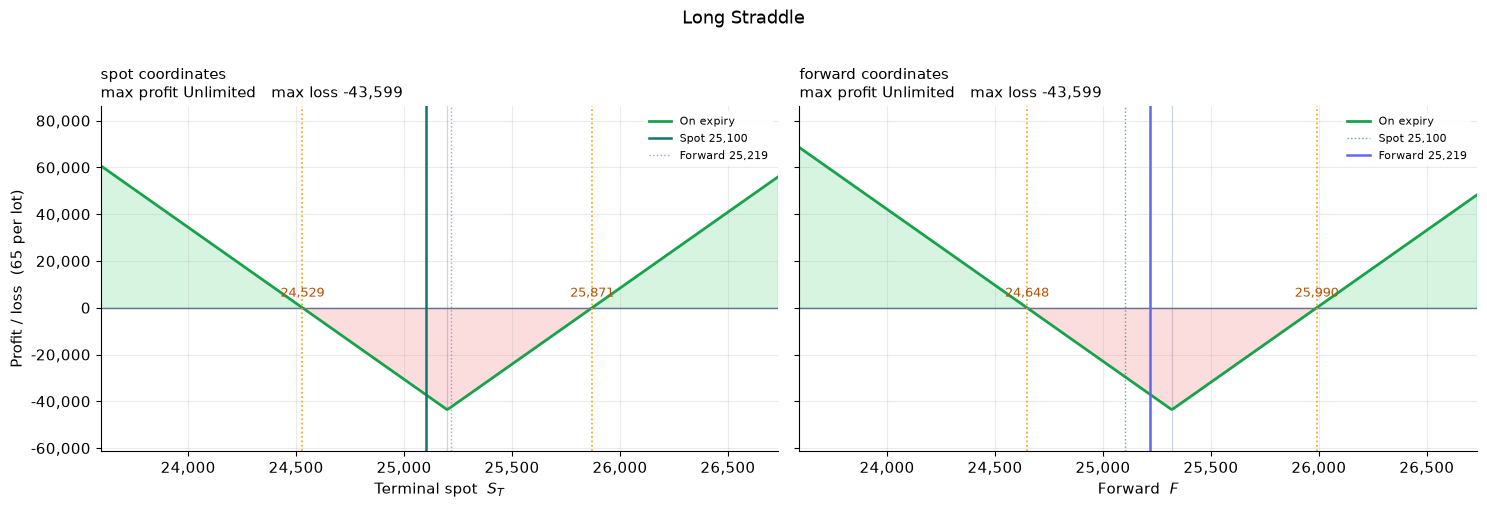

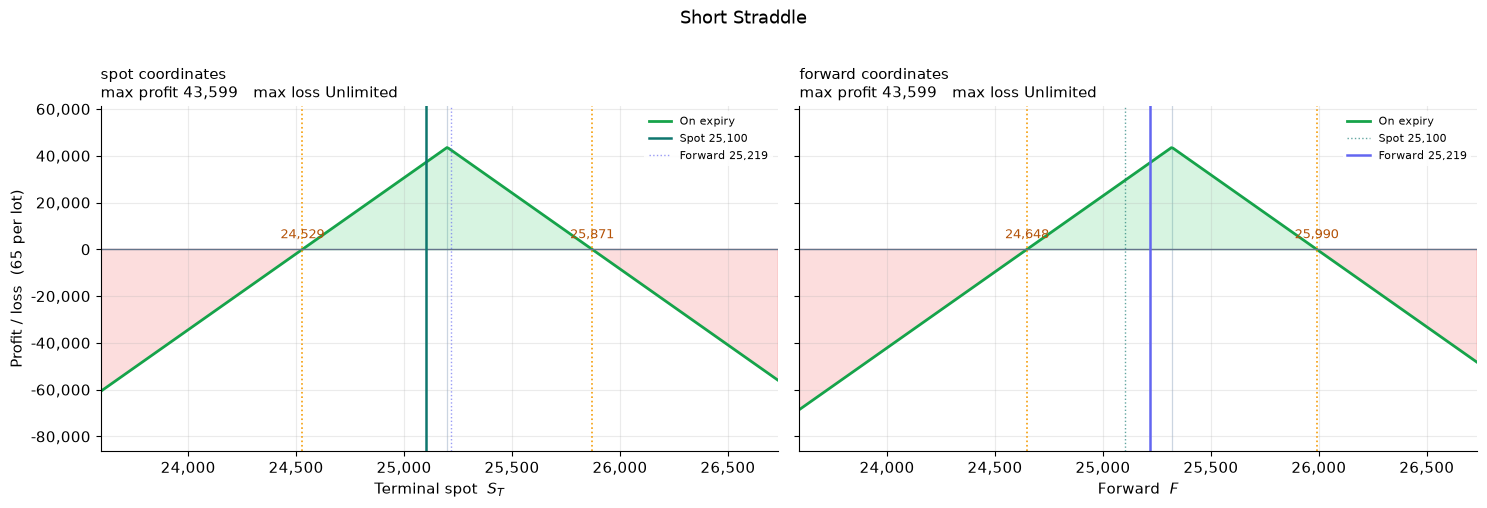

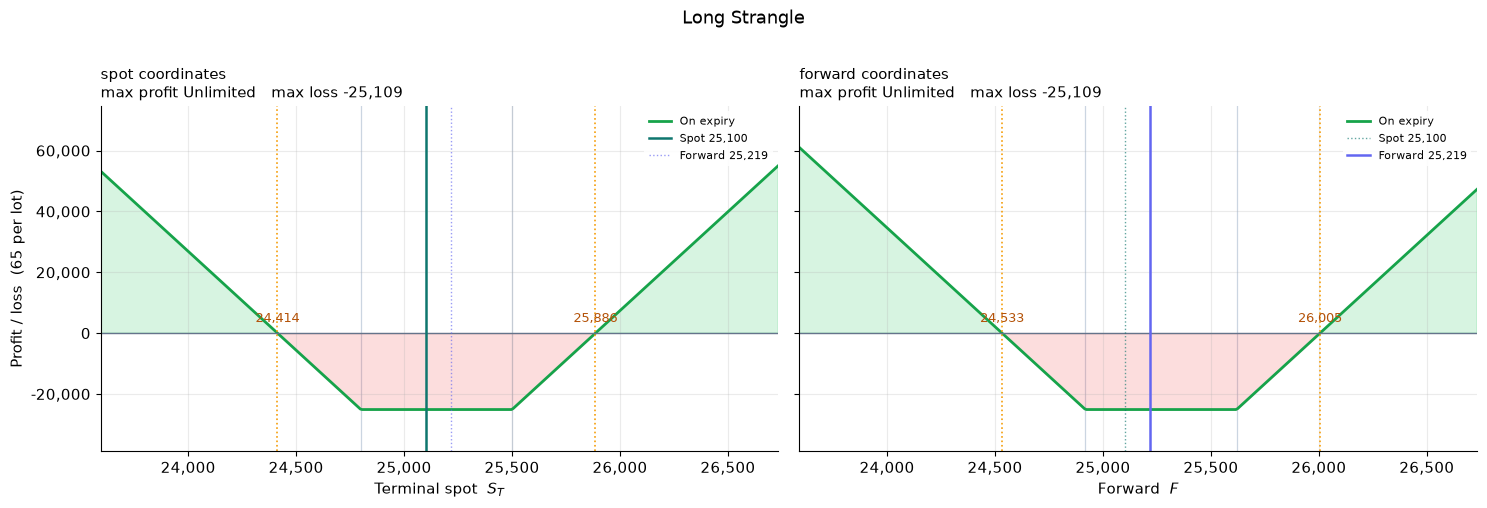

In [11]:
for name in ["Long Straddle", "Short Straddle", "Long Strangle"]:
    plot_pair(name)

### Vertical spreads — credit and debit

Two legs, same type, same expiry, different strikes $K_{\text{lo}} < K_{\text{hi}}$, opposite signs.
Every call is matched by a call and every put by a put, so

$$s_{\text{left}} = s_{\text{right}} = 0$$

Both tails flat: **defined risk on both sides**, with no wings to buy. The whole range is the width,

$$\text{max profit} - \text{max loss} = wL, \qquad w = K_{\text{hi}} - K_{\text{lo}}$$

and the premium decides where inside that range zero sits:

$$\textbf{credit:}\quad \text{max profit} = \text{credit}, \quad \text{max loss} = \text{credit} - wL$$
$$\textbf{debit:}\quad \text{max loss} = -\,\text{debit}, \quad \text{max profit} = wL - \text{debit}$$

$w$ is a difference of strikes, so $b$ cancels: **the width relation is the same in both
coordinate systems**, and so are both caps.

One breakeven — the near strike moved by the premium per unit, then by the basis:

$$S_T^{*} = K_{\text{lo}} + \frac{|\text{net}|}{L} \;\;\text{(calls)}
\qquad
S_T^{*} = K_{\text{hi}} - \frac{|\text{net}|}{L} \;\;\text{(puts)}$$

$$F^{*} = K_{\text{lo}} + b + \frac{|\text{net}|}{L}
\qquad
F^{*} = K_{\text{hi}} + b - \frac{|\text{net}|}{L}$$

Here $w = 300$ on both sides of 25200, so $wL = 300 \times 65 = 19{,}500$.

**Bull Call Spread — debit.** Buy 25200 CE @ 344.05, sell 25500 CE @ 206.20.

$$\text{net} = (344.05 - 206.20) \times 65 = 137.85 \times 65 = 8{,}960.25 \quad\text{(debit)}$$
$$\text{max loss} = -8{,}960.25 \qquad \text{max profit} = 19{,}500 - 8{,}960.25 = 10{,}539.75$$
$$S_T^{*} = 25200 + 137.85 = 25{,}337.85 \;\longrightarrow\; F^{*} = 25{,}456.72$$

**Bear Call Spread — credit.** The same two strikes, signs reversed.

$$\text{credit} = 137.85 \times 65 = 8{,}960.25$$
$$\text{max profit} = 8{,}960.25 \qquad \text{max loss} = 8{,}960.25 - 19{,}500 = -10{,}539.75$$
$$S_T^{*} = 25{,}337.85 \;\longrightarrow\; F^{*} = 25{,}456.72$$

**Bull Put Spread — credit.** Sell 25200 PE @ 326.70, buy 24900 PE @ 208.05.

$$\text{credit} = (326.70 - 208.05) \times 65 = 118.65 \times 65 = 7{,}712.25$$
$$\text{max profit} = 7{,}712.25 \qquad \text{max loss} = 7{,}712.25 - 19{,}500 = -11{,}787.75$$
$$S_T^{*} = 25200 - 118.65 = 25{,}081.35 \;\longrightarrow\; F^{*} = 25{,}200.22$$

**Bear Put Spread — debit.** The same two strikes, signs reversed.

$$\text{debit} = 7{,}712.25$$
$$\text{max loss} = -7{,}712.25 \qquad \text{max profit} = 19{,}500 - 7{,}712.25 = 11{,}787.75$$
$$S_T^{*} = 25{,}081.35 \;\longrightarrow\; F^{*} = 25{,}200.22$$

Each credit/debit pair is an exact mirror: same $|\text{net}|$, same breakeven, caps swapped.
Selling a spread is buying the opposite one.

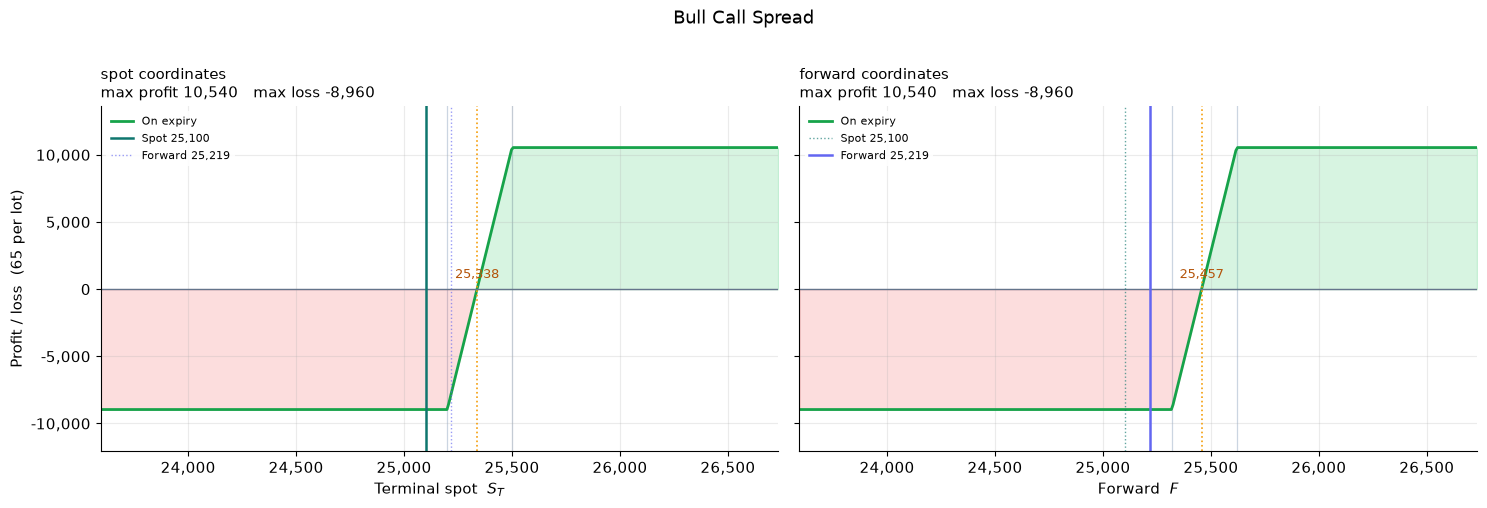

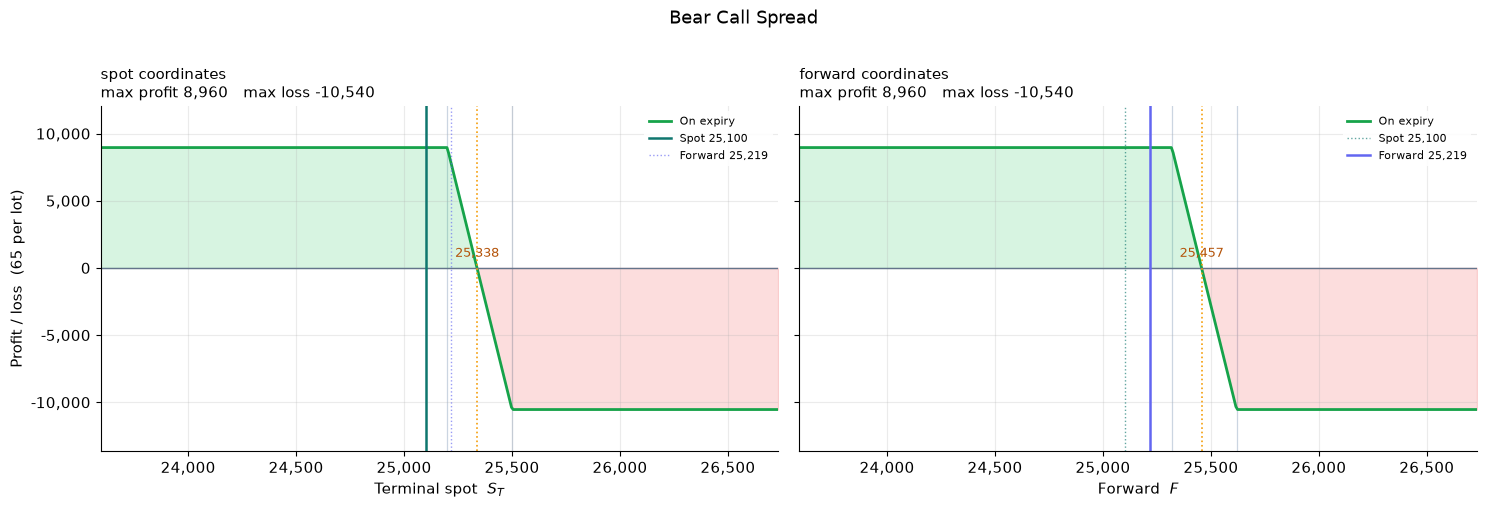

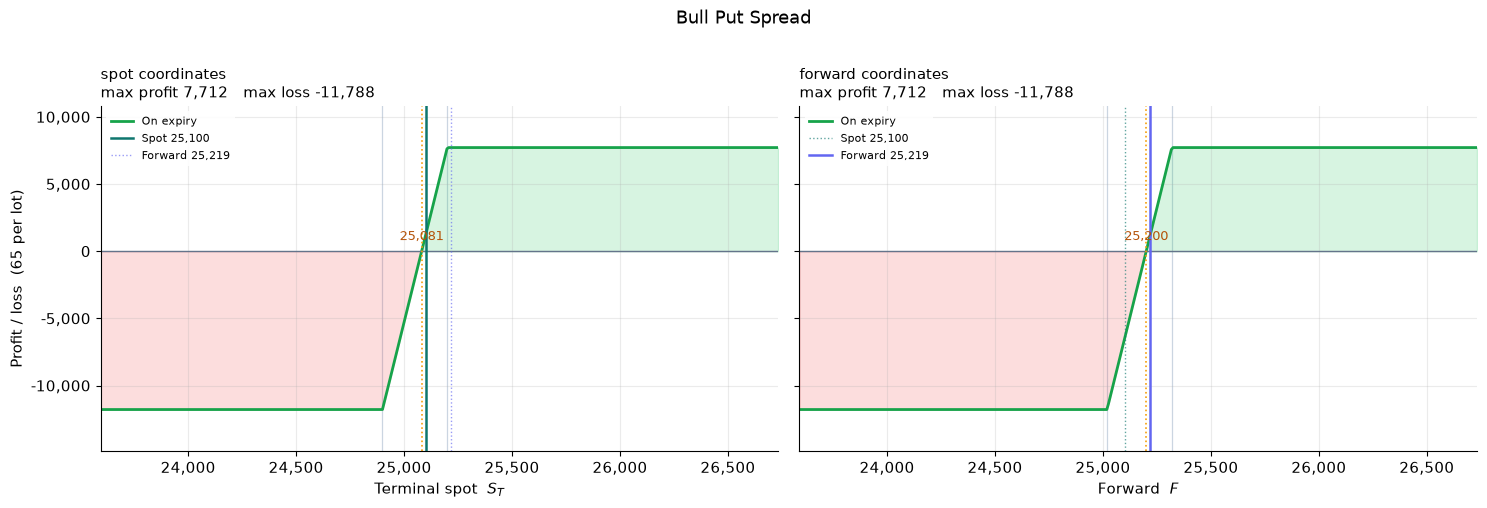

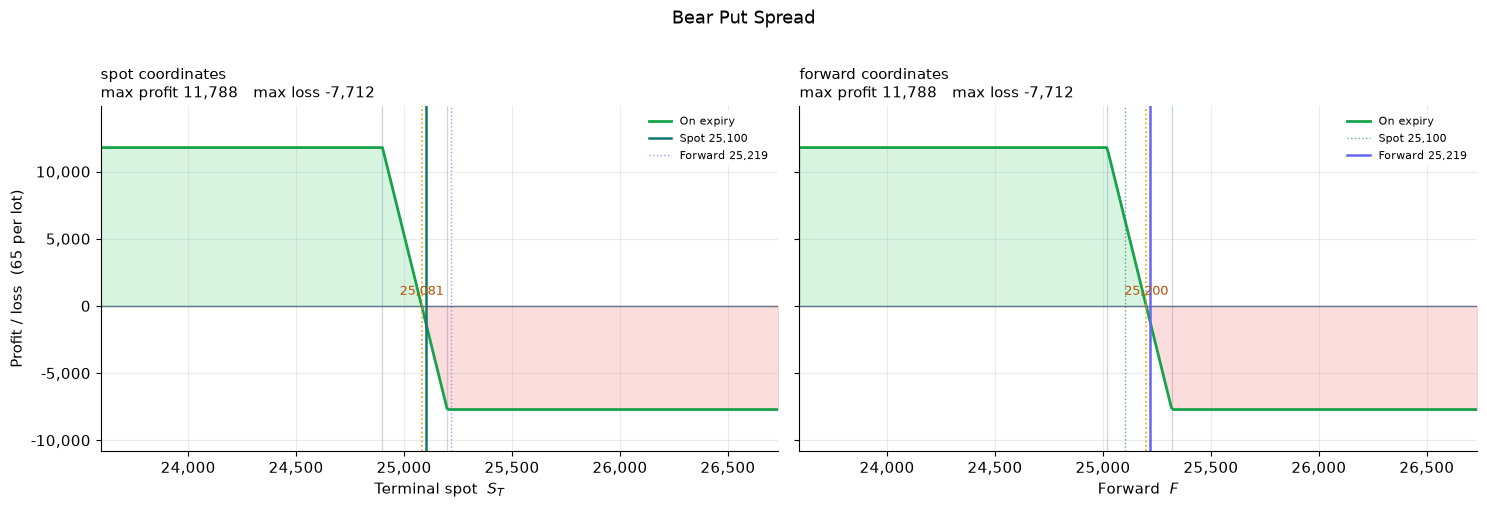

In [12]:
SPREADS = ["Bull Call Spread", "Bear Call Spread", "Bull Put Spread", "Bear Put Spread"]

for name in SPREADS:
    plot_pair(name)

#### Spread caps against the arithmetic

Every claim above, asserted against the engine in **both** coordinate systems — the width relation,
the credit and debit caps, and the breakeven. The caps and the width are framing-independent; the
breakeven formula picks up $b$. These fail the notebook, and the `execute` CI job, if the engine
ever disagrees.

In [13]:
for framing in FRAMINGS:
    print(f"{framing.name} coordinates")
    for name in SPREADS:
        legs = STRATEGIES[name]
        m = metrics_in(legs, framing, LOT_SIZE)
        k_lo, k_hi = sorted(leg.strike for leg in legs)
        w = k_hi - k_lo
        span = w * LOT_SIZE
        net = m["net_premium"]

        assert m["left_slope"] == 0 and m["right_slope"] == 0, f"{name} has an open tail"
        assert abs((m["max_profit"] - m["max_loss"]) - span) < 1e-6, f"{name}: range != w x lot"

        if net < 0:
            credit, kind = -net, "credit"
            assert abs(m["max_profit"] - credit) < 1e-6, f"{name}: max profit != credit"
            assert abs(m["max_loss"] - (credit - span)) < 1e-6, f"{name}: max loss != credit - wL"
        else:
            kind = "debit"
            assert abs(m["max_loss"] + net) < 1e-6, f"{name}: max loss != -debit"
            assert abs(m["max_profit"] - (span - net)) < 1e-6, f"{name}: max profit != wL - debit"

        calls = all(leg.is_call for leg in legs)
        near = k_lo + framing.shift if calls else k_hi + framing.shift
        expected_be = near + abs(net) / LOT_SIZE if calls else near - abs(net) / LOT_SIZE
        assert len(m["breakevens"]) == 1, f"{name}: expected exactly one breakeven"
        assert abs(m["breakevens"][0] - expected_be) < 0.01, f"{name}: breakeven off formula"

        print(f"  {name:<18} {k_lo + framing.shift:,.2f}/{k_hi + framing.shift:,.2f}  "
              f"w {w:>3,.0f} x {LOT_SIZE} = {span:>7,.0f}   {abs(net):>9,.2f} {kind:<6}  "
              f"max profit {m['max_profit']:>10,.2f}   max loss {m['max_loss']:>11,.2f}   "
              f"breakeven {m['breakevens'][0]:,.2f}")
    print()

spot coordinates
  Bull Call Spread   25,200.00/25,500.00  w 300 x 65 =  19,500    8,960.25 debit   max profit  10,539.75   max loss   -8,960.25   breakeven 25,337.85
  Bear Call Spread   25,200.00/25,500.00  w 300 x 65 =  19,500    8,960.25 credit  max profit   8,960.25   max loss  -10,539.75   breakeven 25,337.85
  Bull Put Spread    24,900.00/25,200.00  w 300 x 65 =  19,500    7,712.25 credit  max profit   7,712.25   max loss  -11,787.75   breakeven 25,081.35
  Bear Put Spread    24,900.00/25,200.00  w 300 x 65 =  19,500    7,712.25 debit   max profit  11,787.75   max loss   -7,712.25   breakeven 25,081.35

forward coordinates
  Bull Call Spread   25,318.87/25,618.87  w 300 x 65 =  19,500    8,960.25 debit   max profit  10,539.75   max loss   -8,960.25   breakeven 25,456.72
  Bear Call Spread   25,318.87/25,618.87  w 300 x 65 =  19,500    8,960.25 credit  max profit   8,960.25   max loss  -10,539.75   breakeven 25,456.72
  Bull Put Spread    25,018.87/25,318.87  w 300 x 65 =  19,500

### Iron condor and iron fly

Wings bought beyond each short leg turn what would otherwise be an unbounded loss into a known one.

- **Iron fly** — short ATM straddle, wings 300 points out.
- **Iron condor** — short strangle 300 out, wings 600 out.

Four legs each, no new code.

**Iron condor** — sell 25500 CE @ 206.20 and 24900 PE @ 208.05, buy 25800 CE @ 115.60 and
24600 PE @ 130.20.

$$-206.20 - 208.05 + 115.60 + 130.20 = -168.45
\;\Rightarrow\; -168.45 \times 65 = -10{,}949.25 \quad \text{(credit)}$$

Both wings bought $\Rightarrow s_{\text{left}} = s_{\text{right}} = 0$: both tails flat, both caps
finite.

$$\text{max profit} = \text{credit} = 10{,}949.25$$

$$\text{max loss} = \text{credit} - wL = 10{,}949.25 - 300 \times 65 = -8{,}550.75$$

The credit erodes outward from each short strike:

$$24900 - 168.45 = 24{,}731.55 \qquad 25500 + 168.45 = 25{,}668.45$$

In forward coordinates:

$$24{,}731.55 \,/\, 25{,}668.45 \;\;\longrightarrow\;\; 24{,}850.42 \,/\, 25{,}787.32$$

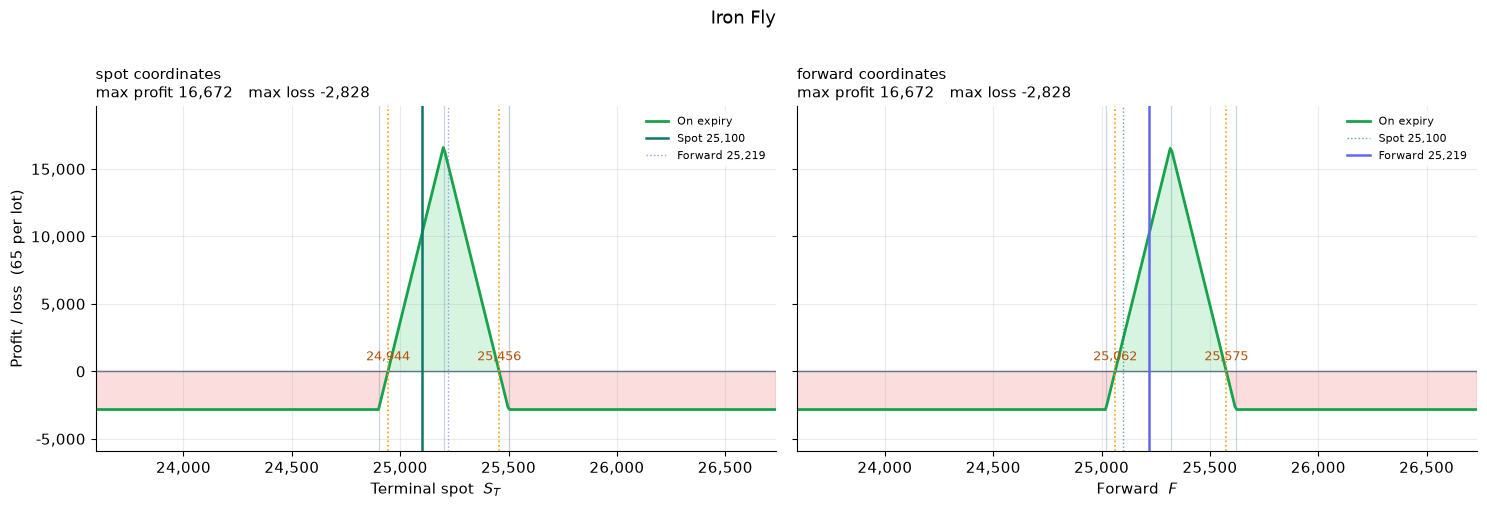

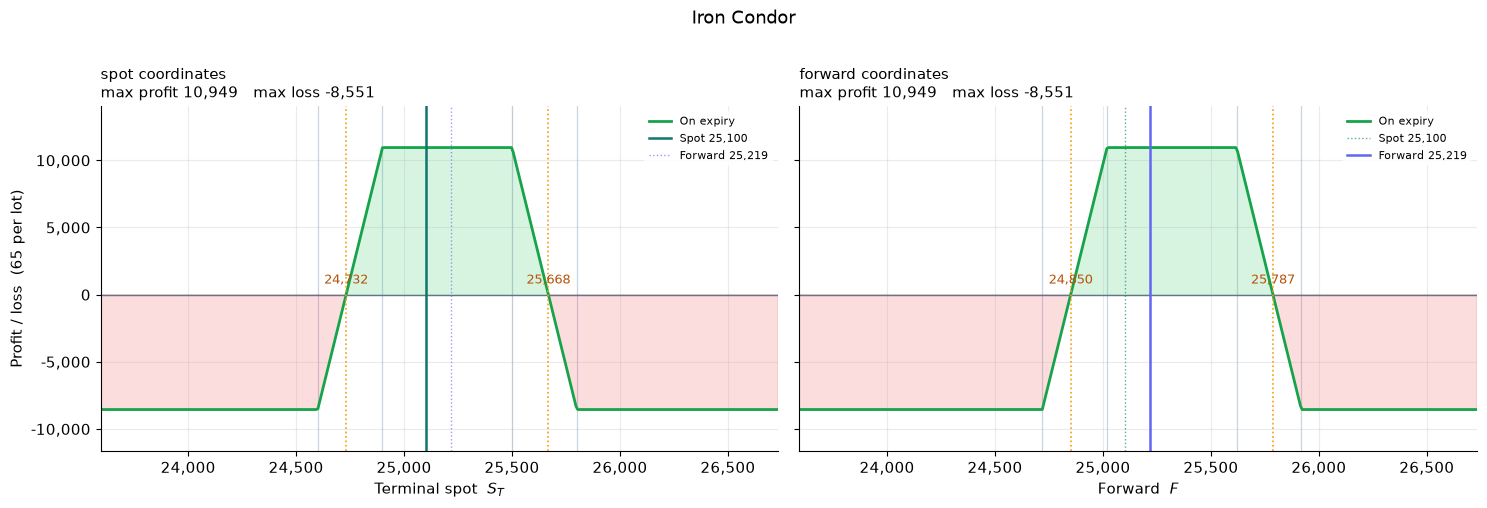

In [14]:
for name in ["Iron Fly", "Iron Condor"]:
    plot_pair(name)

#### Caps against the arithmetic

For a credit structure with both tails flat, the caps are forced by the wings:

$$\text{max profit} = \text{credit}
\qquad
\text{max loss} = \text{credit} - w_{\max} L,
\qquad w_{\max} = \max\bigl(w_{\text{left}},\, w_{\text{right}}\bigr)$$

The **wider** wing sets the loss. The two tails are flat at $\text{credit} - w_{\text{left}}L$ and
$\text{credit} - w_{\text{right}}L$, and the cap is the lower of them.

At this anchor both structures come out symmetric, so $w_{\max}$ collapses to plain $w$ and the
general form looks like decoration. **It is not.** The chain has gaps: 25,400 CE is not quoted, so
a fly built at the *spot*-nearest strike instead lands its call wing 400 points out against 300 on
the put side, and $\text{credit} - wL$ would be wrong. The cell below prints those widths as
evidence — that fly is not a position drawn anywhere here, only a demonstration that the
generalisation is load-bearing.

In [15]:
# Not a position we draw - evidence that w_max is load-bearing.
_, spot_strikes = build_strategies(min(both_sides, key=lambda k: abs(k - SPOT)))
print(f"a fly built at the spot-nearest strike {spot_strikes['atm']:,.0f} would have wings "
      f"{spot_strikes['atm'] - spot_strikes['fly_put']:,.0f} put / "
      f"{spot_strikes['fly_call'] - spot_strikes['atm']:,.0f} call   (25,400 CE is not quoted)\n")

for framing in FRAMINGS:
    print(f"{framing.name} coordinates")
    for name, put_width, call_width in [
        ("Iron Fly",    STRIKES["atm"] - STRIKES["fly_put"],
                        STRIKES["fly_call"] - STRIKES["atm"]),
        ("Iron Condor", STRIKES["fly_put"] - STRIKES["con_put"],
                        STRIKES["con_call"] - STRIKES["fly_call"]),
    ]:
        m = metrics_in(STRATEGIES[name], framing, LOT_SIZE)

        credit = -m["net_premium"]                   # net_premium is negative when we are paid
        w_max = max(put_width, call_width)
        risk = w_max * LOT_SIZE
        expected_loss = credit - risk

        assert m["left_slope"] == 0 and m["right_slope"] == 0, f"{name} has an open tail"
        assert abs(m["max_profit"] - credit) < 1e-6, f"{name}: max profit != credit"
        assert abs(m["max_loss"] - expected_loss) < 1e-6, f"{name}: max loss != credit - w_max x lot"

        symmetry = "symmetric" if put_width == call_width else "ASYMMETRIC"
        print(f"  {name}")
        print(f"    wings        {put_width:,.0f} put / {call_width:,.0f} call   ({symmetry}), "
              f"w_max {w_max:,.0f} x {LOT_SIZE} = {risk:,.2f}")
        print(f"    net credit   {credit:,.2f}")
        print(f"    max profit   {m['max_profit']:,.2f}   = credit")
        print(f"    max loss     {m['max_loss']:,.2f}   = credit - w_max x lot")
        print(f"    breakevens   {fmt_bes(m['breakevens'])}")
    print()

a fly built at the spot-nearest strike 25,100 would have wings 300 put / 400 call   (25,400 CE is not quoted)

spot coordinates
  Iron Fly
    wings        300 put / 300 call   (symmetric), w_max 300 x 65 = 19,500.00
    net credit   16,672.50
    max profit   16,672.50   = credit
    max loss     -2,827.50   = credit - w_max x lot
    breakevens   24,943.50, 25,456.50
  Iron Condor
    wings        300 put / 300 call   (symmetric), w_max 300 x 65 = 19,500.00
    net credit   10,949.25
    max profit   10,949.25   = credit
    max loss     -8,550.75   = credit - w_max x lot
    breakevens   24,731.55, 25,668.45

forward coordinates
  Iron Fly
    wings        300 put / 300 call   (symmetric), w_max 300 x 65 = 19,500.00
    net credit   16,672.50
    max profit   16,672.50   = credit
    max loss     -2,827.50   = credit - w_max x lot
    breakevens   25,062.37, 25,575.37
  Iron Condor
    wings        300 put / 300 call   (symmetric), w_max 300 x 65 = 19,500.00
    net credit   10,949.

### Naked call and put

The building blocks. One leg each, same two functions.

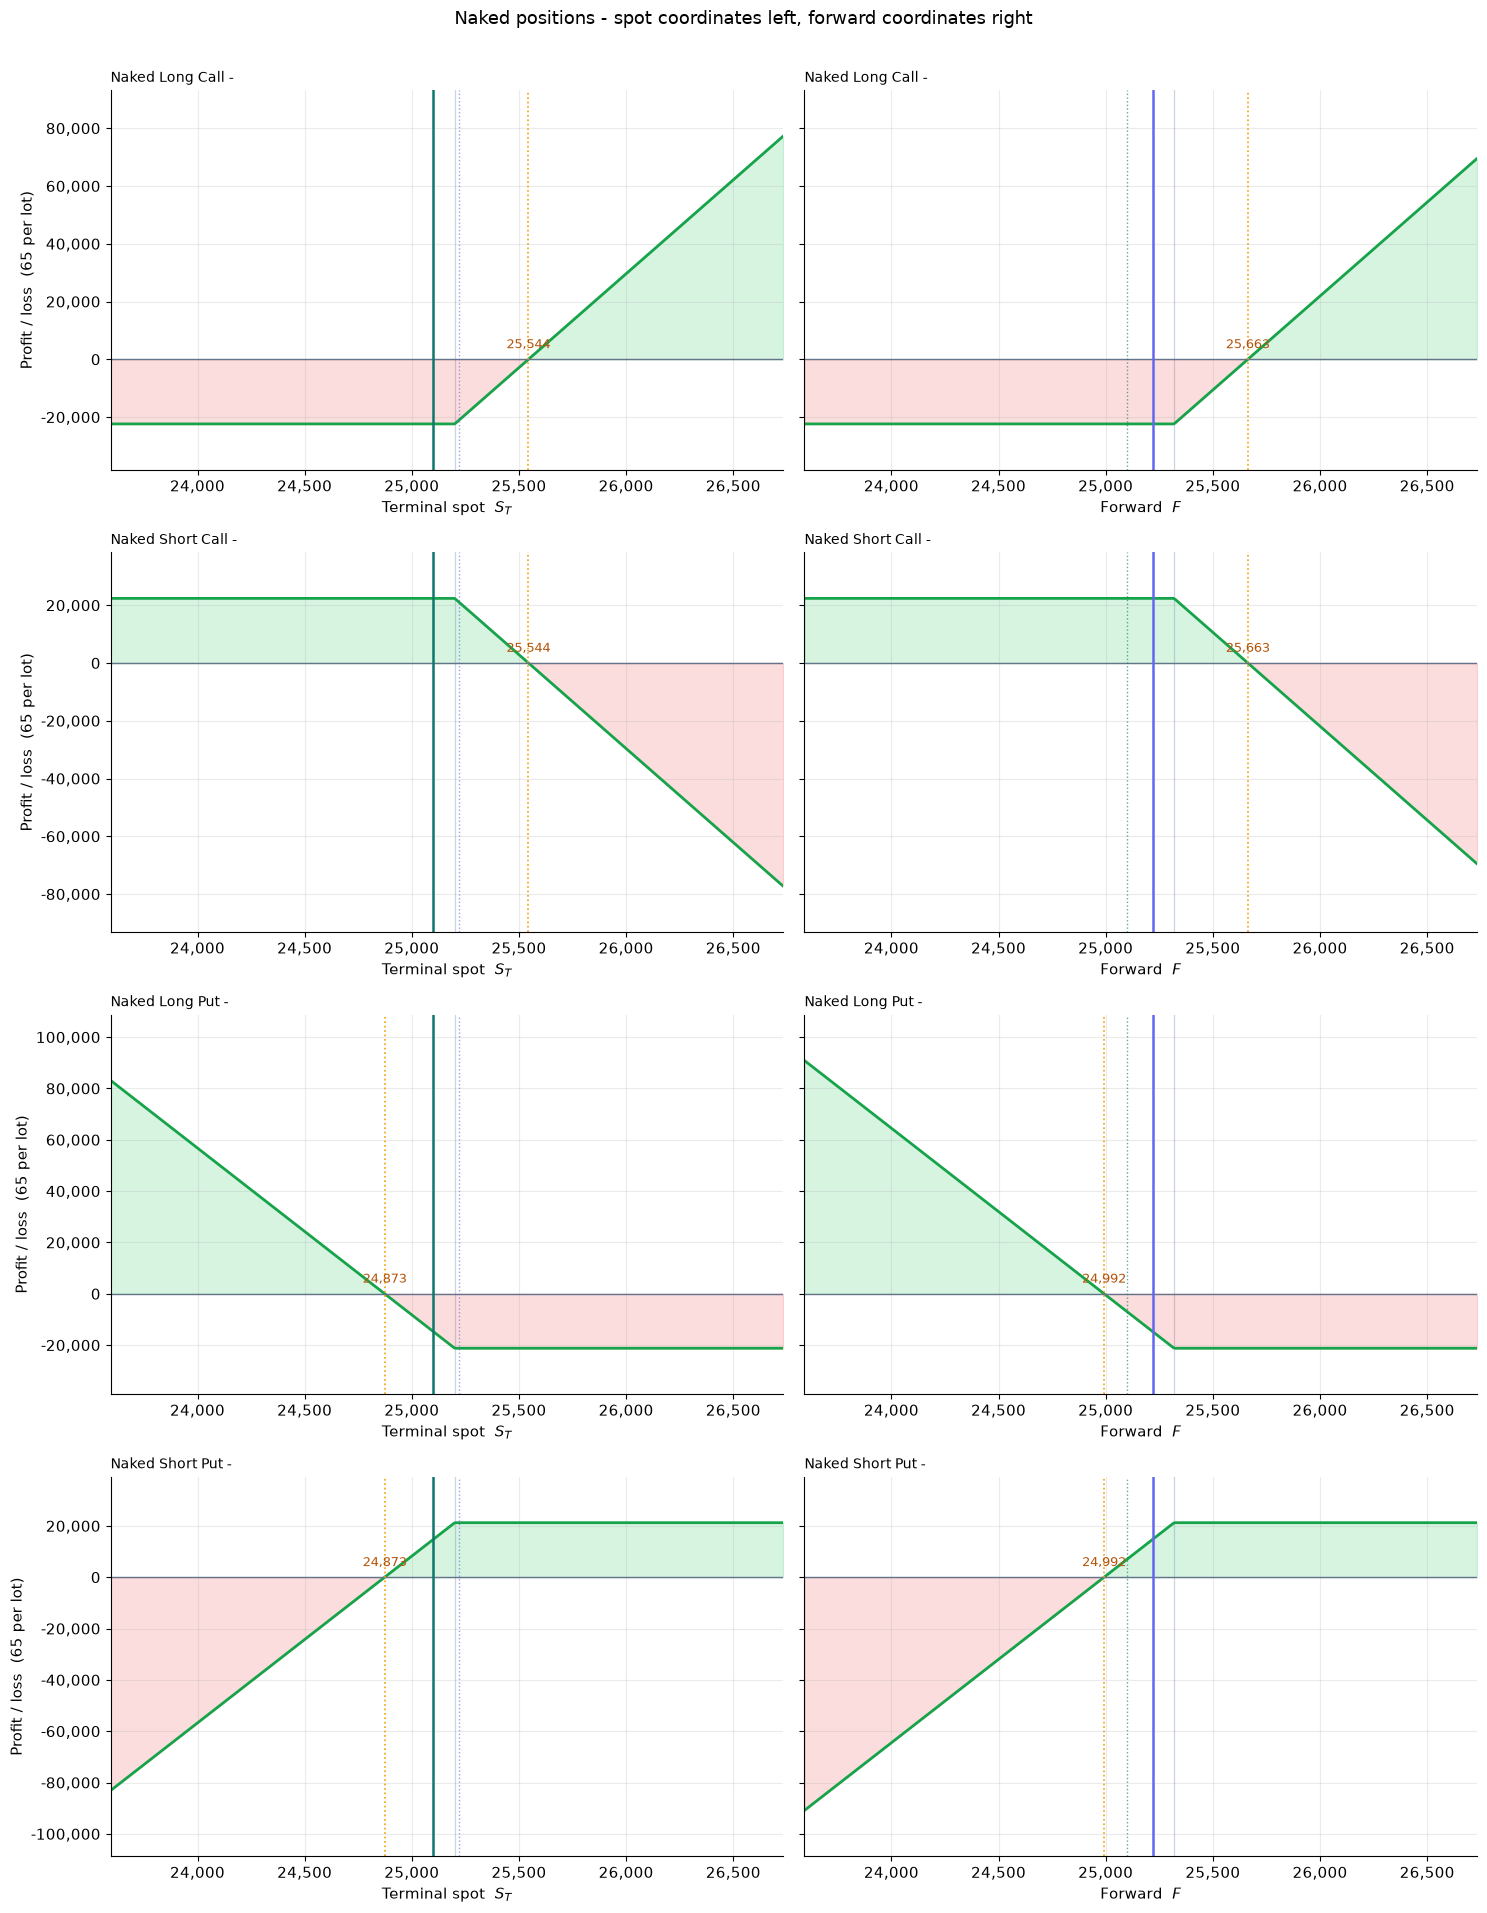

In [16]:
NAKED = ["Naked Long Call", "Naked Short Call", "Naked Long Put", "Naked Short Put"]

fig, axes = plt.subplots(4, 2, figsize=(15, 19), sharey="row")
for row, name in zip(axes, NAKED):
    for ax, framing in zip(row, FRAMINGS):
        plot_strategy(name, framing, ax=ax)
        ax.legend().remove()
        ax.set_title(f"{name} - {ax.get_title()}", fontsize=10, loc="left")
    row[1].set_ylabel("")
fig.suptitle("Naked positions - spot coordinates left, forward coordinates right",
             fontsize=13, y=1.005)
fig.tight_layout()
plt.show()

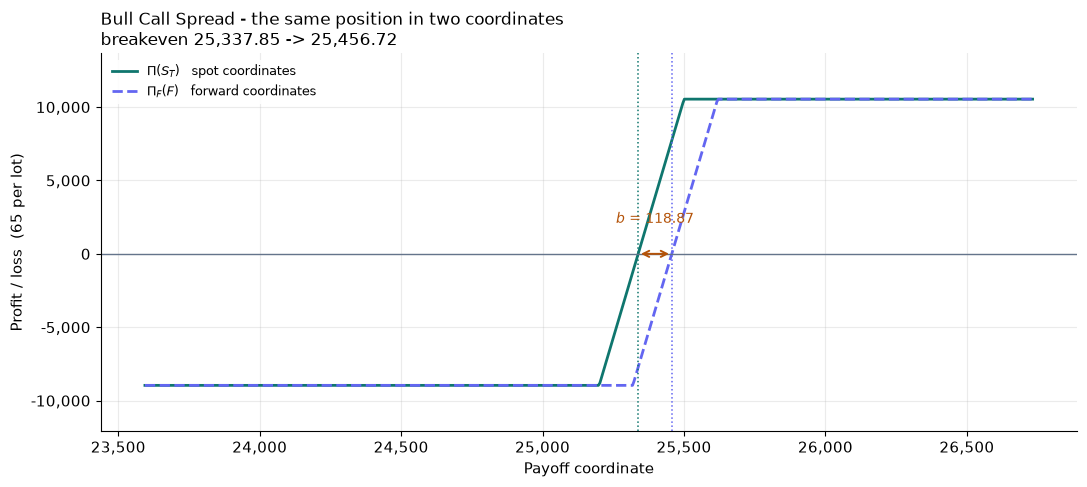

breakeven  spot 25,337.85   forward 25,456.72   difference +118.87   basis +118.87


In [17]:
# The pair plots above already share a frame, so the shift is visible there. This puts both
# curves on the *same* axes to measure it: the gap between the two breakevens is exactly b.
legs = STRATEGIES["Bull Call Spread"]
grid = np.linspace(SPOT * 0.94, FORWARD * 1.06, 600)

spot_curve = payoff_at_expiry(grid, legs, LOT_SIZE)
fwd_curve = payoff_in(grid, legs, FORWARD_FRAMING, LOT_SIZE)

assert np.allclose(fwd_curve, payoff_at_expiry(grid - BASIS, legs, LOT_SIZE)), \
    "the forward curve is not a pure translation of the spot curve"

be_s = metrics_in(legs, SPOT_FRAMING, LOT_SIZE)["breakevens"][0]
be_f = metrics_in(legs, FORWARD_FRAMING, LOT_SIZE)["breakevens"][0]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(grid, spot_curve, color="#0f766e", lw=2.0, label=r"$\Pi(S_T)$   spot coordinates")
ax.plot(grid, fwd_curve, color="#6366f1", lw=2.0, ls="--",
        label=r"$\Pi_F(F)$   forward coordinates")
ax.axhline(0, color="#64748b", lw=1)

ax.annotate("", xy=(be_f, 0), xytext=(be_s, 0),
            arrowprops=dict(arrowstyle="<->", color="#b45309", lw=1.4))
ax.annotate(f"$b$ = {BASIS:,.2f}", ((be_s + be_f) / 2, 0), textcoords="offset points",
            xytext=(0, 22), ha="center", fontsize=10, color="#b45309")
for be, colour in ((be_s, "#0f766e"), (be_f, "#6366f1")):
    ax.axvline(be, color=colour, ls=":", lw=1.1)

ax.set_title(f"Bull Call Spread - the same position in two coordinates\n"
             f"breakeven {be_s:,.2f} -> {be_f:,.2f}", fontsize=12, loc="left")
ax.set_xlabel("Payoff coordinate")
ax.set_ylabel(f"Profit / loss  ({LOT_SIZE} per lot)")
ax.margins(y=0.16)
ax.legend(loc="best", fontsize=9, framealpha=0.9, edgecolor="none", facecolor="white")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:,.0f}")
plt.tight_layout()
plt.show()

print(f"breakeven  spot {be_s:,.2f}   forward {be_f:,.2f}   difference {be_f - be_s:+.2f}"
      f"   basis {BASIS:+.2f}")

## 8. Summary

One row per structure — thirteen positions, not twenty-six. `Dr` is a debit paid, `Cr` a credit
received. The caps belong to the position and are the same in either coordinate system; only the
breakeven columns differ, and they differ by $b$ throughout.

In [18]:
rows = []
for name, legs in STRATEGIES.items():
    ms = metrics_in(legs, SPOT_FRAMING, LOT_SIZE)
    mf = metrics_in(legs, FORWARD_FRAMING, LOT_SIZE)
    rows.append({
        "Strategy": name,
        "Legs": ", ".join(repr(leg) for leg in legs),
        "Max Profit": fmt(ms["max_profit"]),
        "Max Loss": fmt(ms["max_loss"]),
        "Breakeven(s) S_T": fmt_bes(ms["breakevens"]),
        "Breakeven(s) F": fmt_bes(mf["breakevens"]),
        "Net Premium": f"{abs(ms['net_premium']):,.0f} {'Dr' if ms['net_premium'] > 0 else 'Cr'}",
    })

summary = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 30)
summary

,Strategy,Legs,Max Profit,Max Loss,Breakeven(s) S_T,Breakeven(s) F,Net Premium
0,Long Straddle,"B 1x 25200 CE @ 344.05, B 1x 25200 PE @ 326.70",Unlimited,"-43,599","24,529.25, 25,870.75","24,648.12, 25,989.62","43,599 Dr"
1,Short Straddle,"S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70","43,599",Unlimited,"24,529.25, 25,870.75","24,648.12, 25,989.62","43,599 Cr"
2,Long Strangle,"B 1x 25500 CE @ 206.20, B 1x 24800 PE @ 180.10",Unlimited,"-25,109","24,413.70, 25,886.30","24,532.57, 26,005.17","25,109 Dr"
3,Bull Call Spread,"B 1x 25200 CE @ 344.05, S 1x 25500 CE @ 206.20","10,540","-8,960","25,337.85","25,456.72","8,960 Dr"
4,Bear Call Spread,"S 1x 25200 CE @ 344.05, B 1x 25500 CE @ 206.20","8,960","-10,540","25,337.85","25,456.72","8,960 Cr"
5,Bull Put Spread,"S 1x 25200 PE @ 326.70, B 1x 24900 PE @ 208.05","7,712","-11,788","25,081.35","25,200.22","7,712 Cr"
6,Bear Put Spread,"B 1x 25200 PE @ 326.70, S 1x 24900 PE @ 208.05","11,788","-7,712","25,081.35","25,200.22","7,712 Dr"
7,Iron Fly,"S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70, B 1x 255...","16,672","-2,828","24,943.50, 25,456.50","25,062.37, 25,575.37","16,672 Cr"
8,Iron Condor,"S 1x 25500 CE @ 206.20, S 1x 24900 PE @ 208.05, B 1x 258...","10,949","-8,551","24,731.55, 25,668.45","24,850.42, 25,787.32","10,949 Cr"
9,Naked Long Call,B 1x 25200 CE @ 344.05,Unlimited,"-22,363","25,544.05","25,662.92","22,363 Dr"


### What the framing changes

Almost nothing — and that is the claim being made, so it is asserted rather than asserted-looking.

$\Pi_F(F) = \Pi(F - b)$ is a translation, so **max profit, max loss and net premium are identical**
and **every breakeven moves by exactly $b = 118.87$**. The table below is that proof, structure by
structure; the notebook fails if any row disagrees.

The last check is the guard against the $\mathcal{K}_F$ trap: the naked long put's max profit must
read 1,616,764.50 in both coordinates. Re-deriving the candidate set in forward space with $0$
instead of $b$ returns 1,624,490.77 — plausible, 0.48% high, and silent.

In [19]:
rows = []
for name, legs in STRATEGIES.items():
    ms = metrics_in(legs, SPOT_FRAMING, LOT_SIZE)
    mf = metrics_in(legs, FORWARD_FRAMING, LOT_SIZE)

    # 1. the caps and the premium do not move
    assert ms["max_profit"] == mf["max_profit"], f"{name}: max profit moved"
    assert ms["max_loss"] == mf["max_loss"], f"{name}: max loss moved"
    assert ms["net_premium"] == mf["net_premium"], f"{name}: net premium moved"

    # 2. every breakeven moves by exactly the basis
    assert len(ms["breakevens"]) == len(mf["breakevens"]), f"{name}: breakeven count changed"
    shifts = [z - a for a, z in zip(ms["breakevens"], mf["breakevens"])]
    for s in shifts:
        assert abs(s - BASIS) < 0.01, f"{name}: breakeven shift {s:.4f} != basis {BASIS:.4f}"

    # 3. the whole curve is a translation, not just the six numbers
    grid = np.linspace(SPOT * 0.94, FORWARD * 1.06, 600)
    assert np.allclose(payoff_in(grid, legs, FORWARD_FRAMING, LOT_SIZE),
                       payoff_at_expiry(grid - BASIS, legs, LOT_SIZE)), f"{name}: not a translation"

    rows.append({
        "Strategy": name,
        "Max Profit": fmt(ms["max_profit"]),
        "Max Loss": fmt(ms["max_loss"]),
        "Caps move": "no",
        "Net moves": "no",
        "Breakevens": len(ms["breakevens"]),
        "Shift": ", ".join(f"{s:+.2f}" for s in shifts) or "-",
    })

# The regression guard for the forward-coordinate candidate set.
for framing in FRAMINGS:
    mp = metrics_in(STRATEGIES["Naked Long Put"], framing, LOT_SIZE)["max_profit"]
    assert abs(mp - 1_616_764.50) < 0.01, f"{framing.name}: naked long put max profit is {mp:,.2f}"

print(f"all {len(STRATEGIES)} structures: caps and net premium identical, "
      f"every breakeven shifted by exactly {BASIS:+.2f}")
print(f"naked long put max profit 1,616,764.50 in both coordinates "
      f"(the F = 0 trap would read 1,624,490.77)")
pd.DataFrame(rows)

all 13 structures: caps and net premium identical, every breakeven shifted by exactly +118.87
naked long put max profit 1,616,764.50 in both coordinates (the F = 0 trap would read 1,624,490.77)


,Strategy,Max Profit,Max Loss,Caps move,Net moves,Breakevens,Shift
0,Long Straddle,Unlimited,"-43,599",no,no,2,"+118.87, +118.87"
1,Short Straddle,"43,599",Unlimited,no,no,2,"+118.87, +118.87"
2,Long Strangle,Unlimited,"-25,109",no,no,2,"+118.87, +118.87"
3,Bull Call Spread,"10,540","-8,960",no,no,1,+118.87
4,Bear Call Spread,"8,960","-10,540",no,no,1,+118.87
5,Bull Put Spread,"7,712","-11,788",no,no,1,+118.87
6,Bear Put Spread,"11,788","-7,712",no,no,1,+118.87
7,Iron Fly,"16,672","-2,828",no,no,2,"+118.87, +118.87"
8,Iron Condor,"10,949","-8,551",no,no,2,"+118.87, +118.87"
9,Naked Long Call,Unlimited,"-22,363",no,no,1,+118.87
